In [18]:
import pandas as pd

In [19]:
df = pd.read_csv('../data/ab_data.csv')
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [20]:
df.shape

(294478, 5)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [22]:
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [23]:
df = df.drop_duplicates()

In [24]:
conversion_rates = df.groupby('group')['converted'].mean()
print(conversion_rates)

group
control      0.120399
treatment    0.118920
Name: converted, dtype: float64


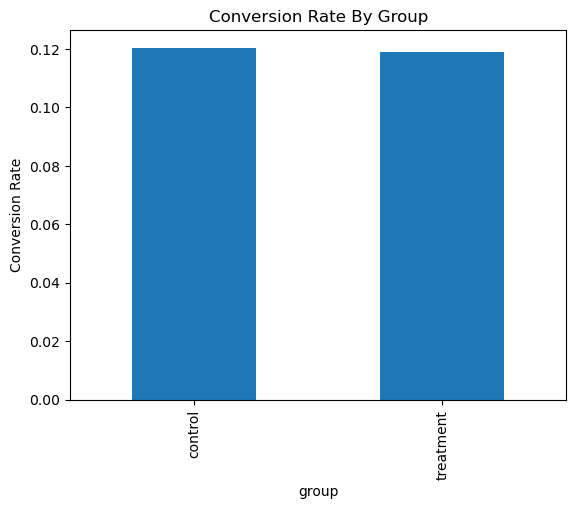

In [25]:
import matplotlib.pyplot as plt

conversion_rates.plot(kind='bar')
plt.title('Conversion Rate By Group')
plt.ylabel('Conversion Rate')
plt.show()

In [26]:
from statsmodels.stats.proportion import proportions_ztest

conversions = df.groupby('group')['converted'].sum()

n = df.groupby('group')['converted'].count()

stat,p_value = proportions_ztest(conversions,n)

print("Z-Stat:",stat)
print("p-value:",p_value)

Z-Stat: 1.2369217547321678
p-value: 0.21611613269757501


In [27]:
control_rate = conversion_rates['control']
treatment_rate = conversion_rates['treatment']

effect_size = treatment_rate - control_rate
print("Effect Size :",effect_size)

Effect Size : -0.0014795997940775518
